## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-01,2010,1,2009-12-07,39.685323,22.639791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.685323,22.639791,14450.0,NaN,39.685323,22.639791,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,2010-01-01,39.650181,22.650104,0.000441,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000441,0.000441
1,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-16,2010,1,2009-12-07,39.685323,22.639791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.685323,22.639791,14278.0,13860.0,39.685323,22.639791,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,2010-01-16,39.650181,22.650104,18.932700,2010-01-09,2010-01-02,2010-01-09,2010-01-02,13.140626,18.916778
2,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-01,2010,1,2009-12-07,39.716764,22.841912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.716764,22.841912,14512.0,14264.0,39.716764,22.841912,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,2010-01-01,39.750182,22.850105,0.029008,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.029008,0.029008
3,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-16,2010,1,2009-12-07,39.716764,22.841912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.716764,22.841912,14141.0,13993.0,39.716764,22.841912,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,2010-01-16,39.750182,22.850105,53.025911,2010-01-09,2010-01-02,2010-01-09,2010-01-02,38.337374,52.420138
4,αγιας,θεσσαλιας,22.84384,39.68498,2010-01-01,2010,1,2009-12-07,39.685323,22.841912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.685323,22.841912,14509.0,14311.0,39.685323,22.841912,14165.700000,14027.777778,14182.769231,13941.538462,14498.500000,14017.562500,14627.230769,14156.714286,2010-01-01,39.650181,22.850105,0.005873,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.005873,0.005873


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14450.0,NaN,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,0.000441,0.000441,0.000441
1,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14278.0,13860.0,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,18.932700,13.140626,18.916778
2,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14512.0,14264.0,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,0.029008,0.029008,0.029008
3,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14141.0,13993.0,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,53.025911,38.337374,52.420138
4,αγιας,θεσσαλιας,22.84384,39.68498,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14509.0,14311.0,14165.700000,14027.777778,14182.769231,13941.538462,14498.500000,14017.562500,14627.230769,14156.714286,0.005873,0.005873,0.005873


In [10]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [11]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")


['ρηγα φεραιου']

Length: 1


In [12]:
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ρηγα φερραιου','ρηγα φεραιου'))

In [13]:
## Check again

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [14]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [15]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14450.0,NaN,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,0.000441,0.000441,0.000441,NaN
1,αγιας,θεσσαλιας,22.64007,39.68498,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14278.0,13860.0,14289.285714,13888.285714,14259.166667,13878.583333,14594.642857,13979.000000,14865.666667,14096.615385,18.932700,13.140626,18.916778,NaN
2,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14512.0,14264.0,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,0.029008,0.029008,0.029008,NaN
3,αγιας,θεσσαλιας,22.84384,39.71642,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14141.0,13993.0,14152.000000,14026.666667,14139.100000,13954.615385,14495.625000,13997.764706,14613.500000,14148.692308,53.025911,38.337374,52.420138,NaN
4,αγιας,θεσσαλιας,22.84384,39.68498,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14509.0,14311.0,14165.700000,14027.777778,14182.769231,13941.538462,14498.500000,14017.562500,14627.230769,14156.714286,0.005873,0.005873,0.005873,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199363,φαρσαλων,θεσσαλιας,22.43571,39.27184,2022-12-16,2022,12,0.313629,0.050328,-0.206030,-0.050328,0.263393,0.017472,-0.192603,-0.017472,0.104094,0.076324,0.075443,0.076324,14427.0,13817.0,14152.100000,13683.666667,14344.000000,13727.727273,14406.833333,13708.454545,14971.058824,14137.125000,866.109682,5.237970,6.596659,NaN
199364,φαρσαλων,θεσσαλιας,22.43571,39.36616,2022-12-01,2022,12,0.049954,-0.194750,-0.076850,0.194750,0.030268,-0.153629,-0.038384,0.153629,0.024616,0.047191,0.055044,0.047191,14463.0,13815.0,14220.157895,13638.833333,14407.066667,13752.818182,14493.666667,13720.909091,14933.066667,14096.400000,1171.923272,13.280452,54.526232,NaN
199365,φαρσαλων,θεσσαλιας,22.43571,39.36616,2022-12-16,2022,12,0.049954,-0.194750,-0.076850,0.194750,0.030268,-0.153629,-0.038384,0.153629,0.024616,0.047191,0.055044,0.047191,14255.0,13815.0,14220.157895,13638.833333,14407.066667,13752.818182,14493.666667,13720.909091,14933.066667,14096.400000,1186.034430,12.043608,13.828264,NaN
199366,φαρσαλων,θεσσαλιας,22.35464,39.33472,2022-12-01,2022,12,0.073130,-0.221346,-0.104041,0.221346,0.132322,-0.209904,-0.155448,0.209904,0.057928,0.022965,0.051536,0.022965,14199.0,13754.0,14153.750000,13612.937500,14469.866667,13722.700000,14602.937500,13669.818182,15220.333333,14112.812500,1326.672675,15.498224,54.754305,NaN


In [16]:
merged = fillna(merged,{'case': 0})

In [17]:
merged['case'].value_counts()

0.0     196818
1.0       1441
2.0        861
3.0        203
4.0         18
7.0          9
5.0          9
13.0         9
Name: case, dtype: int64

In [18]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αγιας,θεσσαλιας,22.761054,39.691860,2010.0,1.0,0.334542,0.076456,-0.204286,-0.076456,0.150538,0.303110,0.239247,-0.303110,0.014625,0.025915,0.041455,0.025915,14460.187500,14154.600000,14212.988811,13903.850694,14139.111854,13855.989507,14500.226929,13953.570064,14623.806281,14064.399627,0.031663,0.031663,0.031663,0.0
1,2010-01-01,αλμυρου,θεσσαλιας,22.726710,39.125600,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14493.979167,14140.000000,14156.948933,13880.178110,14212.100036,13861.793000,14527.620371,13959.537903,14713.322951,14056.167100,0.189728,0.189728,0.189728,0.0
2,2010-01-01,αλοννησου,θεσσαλιας,23.998420,39.245850,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αργιθεας,θεσσαλιας,21.485102,39.296296,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13629.191026,13732.426923,13894.010531,13601.404762,14281.229734,13751.144969,14535.268158,13954.164989,48.433745,48.433745,48.433745,0.0
4,2010-01-01,βολου,θεσσαλιας,22.935020,39.381170,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14520.416667,NaN,14302.047321,13888.258433,14261.104717,13845.971890,14554.853626,13956.490166,14760.628818,14068.163696,0.003329,0.003329,0.003329,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,2022-12-16,τεμπων,θεσσαλιας,22.542882,39.850899,2022.0,12.0,0.462931,0.139847,-0.375995,-0.139847,0.454310,0.116977,-0.379718,-0.116977,0.068989,0.079488,0.061524,0.079488,14325.923077,14121.846154,14002.047541,13695.138386,14193.297749,13776.772390,14272.775984,13735.938709,14797.444770,14119.040086,1033.419139,7.541091,8.626504,0.0
7796,2022-12-16,τρικκαιων,θεσσαλιας,21.774345,39.612926,2022.0,12.0,0.254213,-0.002014,-0.199459,0.002014,0.226314,0.002160,-0.168486,-0.002160,0.040752,0.042605,0.043227,0.042605,14335.681818,13993.000000,14139.701549,13662.548938,14355.249665,13721.006336,14460.529564,13726.233781,14943.095907,14142.780254,1033.129627,34.383863,35.472655,0.0
7797,2022-12-16,τυρναβου,θεσσαλιας,22.296112,39.762971,2022.0,12.0,0.278394,-0.024938,-0.239203,0.024938,0.283631,0.002623,-0.235060,-0.002623,0.047972,0.054109,0.042711,0.054109,14412.875000,13989.625000,14130.213328,13636.450970,14370.773268,13739.709402,14456.696611,13715.624265,15025.864632,14138.208309,1040.061409,27.771836,28.286410,0.0
7798,2022-12-16,φαρκαδονας,θεσσαλιας,22.026290,39.603000,2022.0,12.0,0.216971,-0.121964,-0.212326,0.121964,0.196857,-0.089320,-0.179573,0.089320,0.031331,0.034120,0.036742,0.034120,14419.727273,14029.272727,14115.119538,13693.512606,14366.499342,13762.910680,14461.380253,13775.352709,15059.793236,14185.624777,1062.436085,24.165011,24.540061,0.0


In [19]:
# dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
# dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [20]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [21]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [22]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [23]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [24]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [25]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [26]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [27]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [28]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

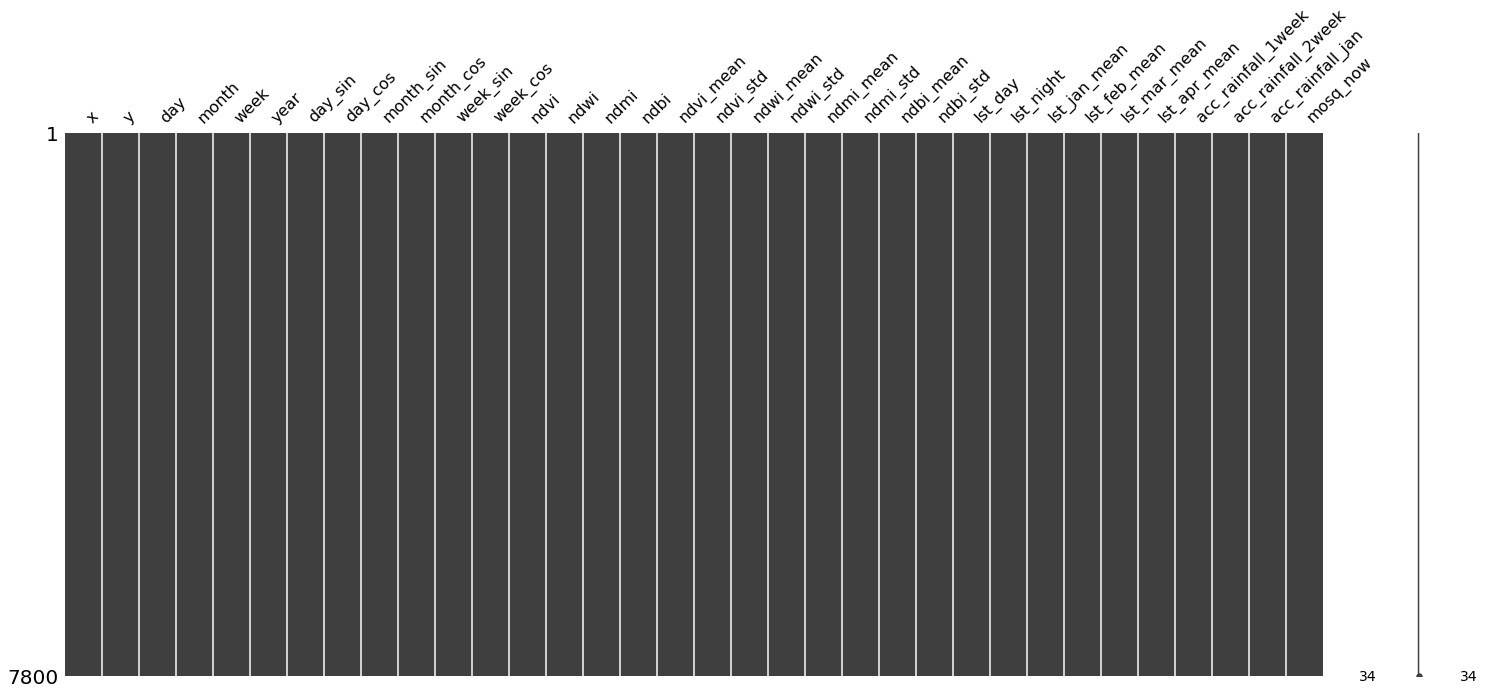

In [29]:
missingno.matrix(dataset_mamoth)

In [30]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [31]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [32]:
predictions = give_predictions(model, dataset_mamoth)

In [33]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.761054,39.691860,2010-01-01,10
1,22.726710,39.125600,2010-01-01,1
2,23.998420,39.245850,2010-01-01,1
3,21.485102,39.296296,2010-01-01,30
4,22.935020,39.381170,2010-01-01,1
...,...,...,...,...
7795,22.542882,39.850899,2022-12-16,36
7796,21.774345,39.612926,2022-12-16,53
7797,22.296112,39.762971,2022-12-16,47
7798,22.026290,39.603000,2022-12-16,56


In [34]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [35]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [36]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [37]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [38]:
dataset.distance.max()

0.0

In [39]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [40]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

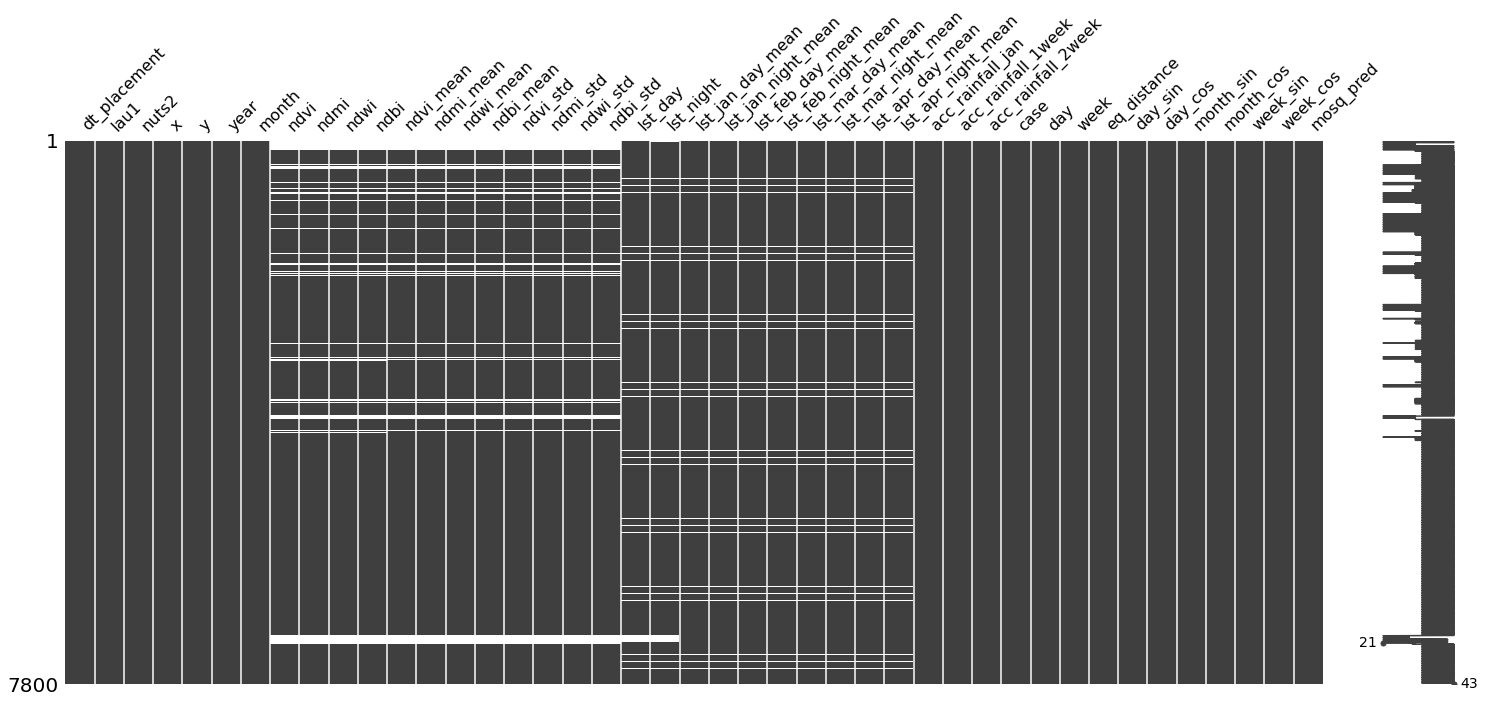

In [42]:
missingno.matrix(dataset)

In [43]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [44]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [45]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [46]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [47]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [48]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

['καλαμπακας', 'λαρισαιων', 'φαρκαδονας']

Length: 3


In [49]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [50]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [51]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

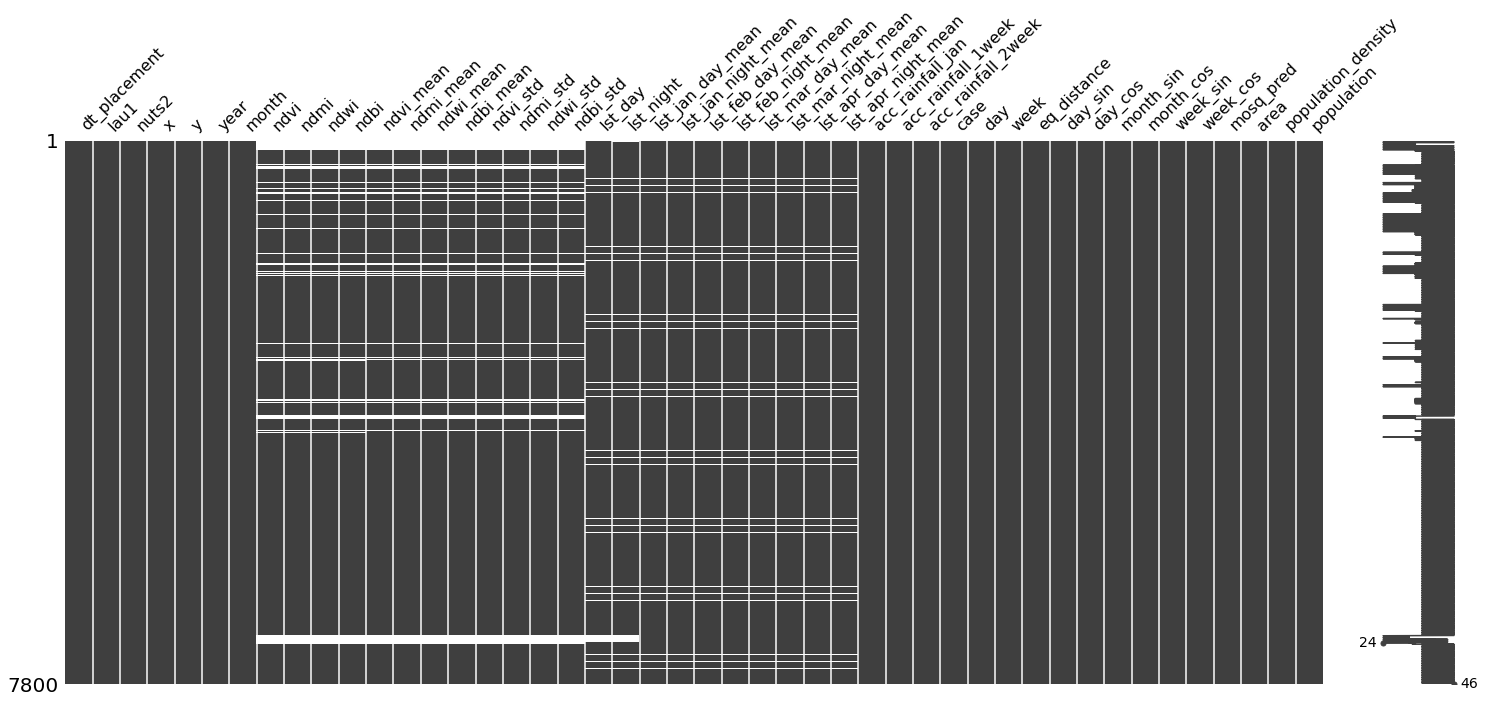

In [52]:
missingno.matrix(dataset)

In [53]:
missing = describe_dataframe(dataset)

In [54]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2010-01-01,αγιας,θεσσαλιας,22.761054,39.691860,2010,1,0.334542,0.076456,-0.204286,-0.076456,0.150538,0.303110,0.239247,-0.303110,0.014625,0.025915,0.041455,0.025915,14460.187500,14154.600000,14212.988811,13903.850694,14139.111854,13855.989507,14500.226929,13953.570064,14623.806281,14064.399627,0.031663,0.031663,0.031663,0,1,53,45.75488,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,10,661.8,17.3,10705.00
1,2010-01-01,αλμυρου,θεσσαλιας,22.726710,39.125600,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14493.979167,14140.000000,14156.948933,13880.178110,14212.100036,13861.793000,14527.620371,13959.537903,14713.322951,14056.167100,0.189728,0.189728,0.189728,0,1,53,45.24728,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,1,905.4,20.6,16004.00
2,2010-01-01,αλοννησου,θεσσαλιας,23.998420,39.245850,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,1,53,46.00175,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,1,129.6,21.2,3153.00
3,2010-01-01,αργιθεας,θεσσαλιας,21.485102,39.296296,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13629.191026,13732.426923,13894.010531,13601.404762,14281.229734,13751.144969,14535.268158,13954.164989,48.433745,48.433745,48.433745,0,1,53,44.78625,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,30,372.9,9.3,3515.00
4,2010-01-01,βολου,θεσσαλιας,22.935020,39.381170,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14520.416667,NaN,14302.047321,13888.258433,14261.104717,13845.971890,14554.853626,13956.490166,14760.628818,14068.163696,0.003329,0.003329,0.003329,0,1,53,45.57293,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,1,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,2022-12-16,τεμπων,θεσσαλιας,22.542882,39.850899,2022,12,0.462931,0.139847,-0.375995,-0.139847,0.454310,0.116977,-0.379718,-0.116977,0.068989,0.079488,0.061524,0.079488,14325.923077,14121.846154,14002.047541,13695.138386,14193.297749,13776.772390,14272.775984,13735.938709,14797.444770,14119.040086,1033.419139,7.541091,8.626504,0,16,50,45.78510,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,36,576.7,23.8,11.99
7796,2022-12-16,τρικκαιων,θεσσαλιας,21.774345,39.612926,2022,12,0.254213,-0.002014,-0.199459,0.002014,0.226314,0.002160,-0.168486,-0.002160,0.040752,0.042605,0.043227,0.042605,14335.681818,13993.000000,14139.701549,13662.548938,14355.249665,13721.006336,14460.529564,13726.233781,14943.095907,14142.780254,1033.129627,34.383863,35.472655,0,16,50,45.20294,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,53,607.6,133.9,78508.00
7797,2022-12-16,τυρναβου,θεσσαλιας,22.296112,39.762971,2022,12,0.278394,-0.024938,-0.239203,0.024938,0.283631,0.002623,-0.235060,-0.002623,0.047972,0.054109,0.042711,0.054109,14412.875000,13989.625000,14130.213328,13636.450970,14370.773268,13739.709402,14456.696611,13715.624265,15025.864632,14138.208309,1040.061409,27.771836,28.286410,0,16,50,45.58739,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,47,525.3,47.7,22252.00
7798,2022-12-16,φαρκαδονας,θεσσαλιας,22.026290,39.603000,2022,12,0.216971,-0.121964,-0.212326,0.121964,0.196857,-0.089320,-0.179573,0.089320,0.031331,0.034120,0.036742,0.034120,14419.727273,14029.272727,14115.119538,13693.512606,14366.499342,13762.9

In [55]:
dataset = calculate_mosq_previous(dataset)

In [56]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

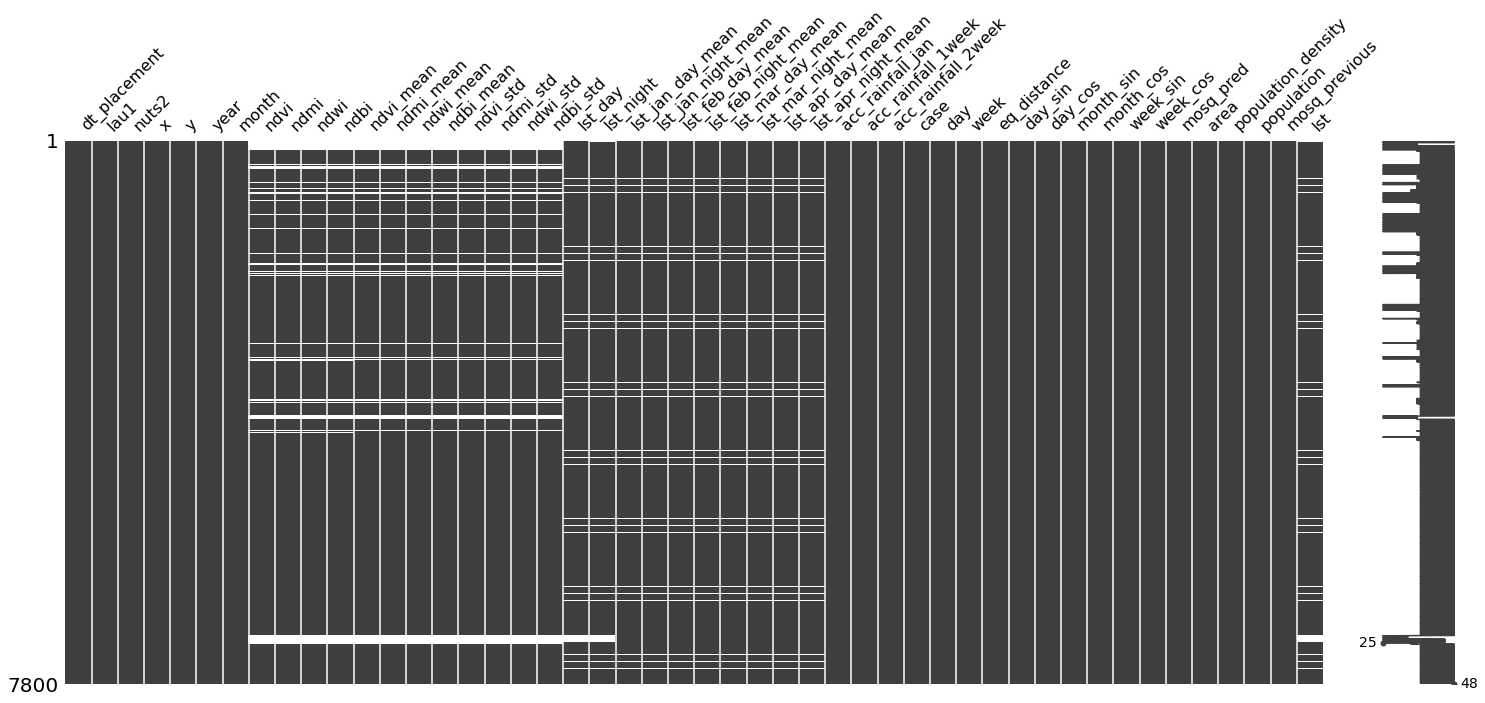

In [57]:
missingno.matrix(dataset)

In [58]:
dataset['case'].value_counts()

0     7712
1       55
2       23
3        5
4        2
7        1
5        1
13       1
Name: case, dtype: int64

In [59]:
dataset.case.sum()

149

In [60]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [61]:
dataset = convert_multiple_cases(dataset)

In [62]:
dataset['case'].value_counts()

0    7712
1     149
Name: case, dtype: int64

In [63]:
dataset.case.sum()

149

In [64]:
cols = dataset.columns

In [65]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [66]:
len(cols)

48

In [67]:
# check columns

In [68]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [69]:
len(final_columns)

48

In [70]:
dataset_final = dataset[final_columns].copy()

In [71]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.761054,39.691860,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.979530,0.5,8.660254e-01,-2.449294e-16,1.00000,661.8,10705.0,17.3,45.75488,0.334542,0.076456,-0.204286,-0.076456,0.150538,0.303110,0.239247,-0.303110,0.014625,0.025915,0.041455,0.025915,12.997875,16.053750,9.942000,11.109776,4.927014,9.632237,3.969790,16.854539,5.921401,19.326126,8.137993,0.031663,0.031663,0.031663,10,0,0
1,22.726710,39.125600,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.979530,0.5,8.660254e-01,-2.449294e-16,1.00000,905.4,16004.0,20.6,45.24728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.189792,16.729583,9.650000,9.988979,4.453562,11.092001,4.085860,17.402407,6.040758,21.116459,7.973342,0.189728,0.189728,0.189728,1,0,0
2,23.998420,39.245850,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.979530,0.5,8.660254e-01,-2.449294e-16,1.00000,129.6,3153.0,21.2,46.00175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0,0
3,21.485102,39.296296,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.979530,0.5,8.660254e-01,-2.449294e-16,1.00000,372.9,3515.0,9.3,44.78625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.566179,1.498538,4.730211,-1.121905,12.474595,1.872899,17.555363,5.933300,48.433745,48.433745,48.433745,30,0,0
4,22.935020,39.381170,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.979530,0.5,8.660254e-01,-2.449294e-16,1.00000,385.6,138865.0,374.6,45.57293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.258333,NaN,12.890946,4.615169,12.072094,3.769438,17.947073,5.979803,22.062576,8.213274,0.003329,0.003329,0.003329,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7856,22.341069,39.610479,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.0,-1.836970e-16,-9.473264e-01,-0.32027,336.0,164381.0,483.9,45.47651,0.250947,-0.116101,-0.283557,0.116101,0.252444,-0.116519,-0.282682,0.116519,0.056709,0.049903,0.041772,0.049903,28.568889,37.418889,19.718889,10.700565,-1.301608,15.631945,1.035034,18.026641,0.634315,27.226818,8.812485,0.000000,30.605289,955.247184,60,159,1
7857,22.341069,39.610479,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.0,-1.836970e-16,-9.473264e-01,-0.32027,336.0,164381.0,483.9,45.47651,0.250947,-0.116101,-0.283557,0.116101,0.252444,-0.116519,-0.282682,0.116519,0.056709,0.049903,0.041772,0.049903,28.568889,37.418889,19.718889,10.700565,-1.301608,15.631945,1.035034,18.026641,0.634315,27.226818,8.812485,0.000000,30.605289,955.247184,60,159,1
7858,22.341069,39.610479,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.0,-1.836970e-16,-9.473264e-01,-0.32027,336.0,164381.0,483.9,45.47651,0.250947,-0.116101,-0.283557,0.116101,0.252444,-0.116519,-0.282682,0.116519,0.056709,0.049903,0.041772,0.049903,28.568889,37.418889,19.718889,10.700565,-1.301608,15.631945,1.035034,18.026641,0.634315,27.226818,8.812485,0.000000,30.605289,955.247184,60,159,1
7859,22.341069,39.610479,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.0,-1.836970e-16,-9.473264e-01,-0.32027,336.0,164381.0,483.9,45.47651,0.250947,-0.116101,-0.283557,0.116101,0.252444,-0.116519,-0.282682,0.116519,0.056709,0.049903,0.041772,0.049903,28.568889,37.418889,19.718889,10.700565,-1.301608,15.631945,1.035034,18.026641,0.634315,27.226818,8.812485,0.000000,30.605289,955.247

In [72]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv", encoding = enc, index = False)